In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


C:\Users\Lab\AppData\Local\Temp\ipykernel_12704\1443559189.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = df.groupby('day')['total_bill'].mean()


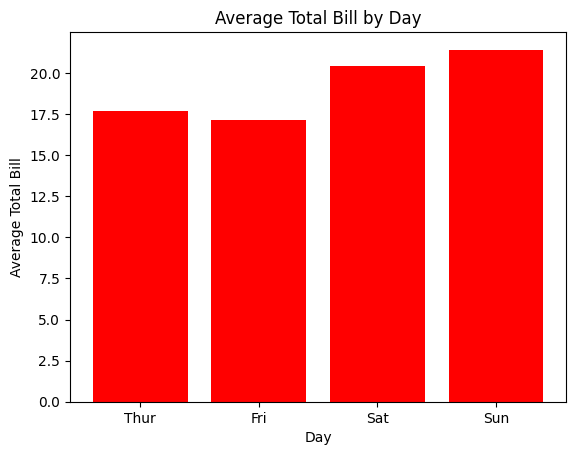

In [31]:
# Task 1

avg = df.groupby('day')['total_bill'].mean()
plt.bar(avg.index, avg.values,color='red')
plt.xlabel('Day')
plt.ylabel('Average Total Bill')
plt.title('Average Total Bill by Day')
plt.show()

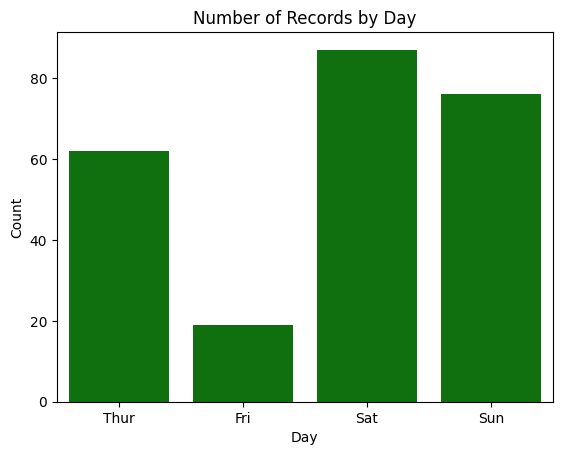

In [32]:
# Task 2
sns.countplot(data=df, x='day',color='green')
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Number of Records by Day')
plt.show()
# Saturday is most common in Day

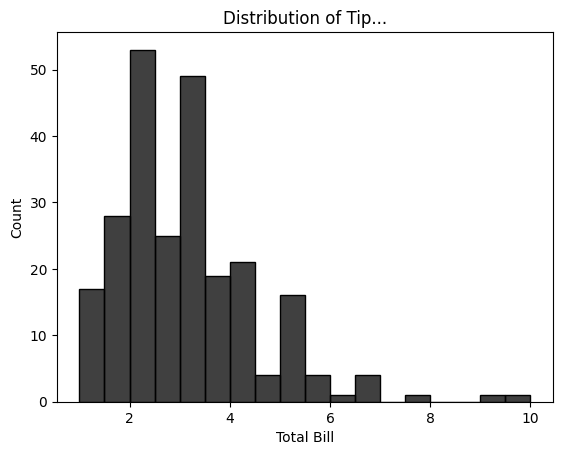

In [33]:
# Task 3
sns.histplot(data=df, x='tip',color='black')
plt.xlabel('Total Bill')
plt.ylabel('Count')
plt.title('Distribution of Tip...')
plt.show()
# Right Skewed as tail falls to right


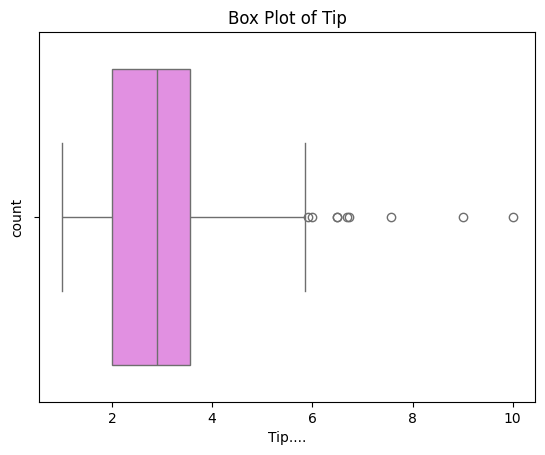

In [29]:
# Task 4
sns.boxplot(x=df["tip"],color='violet')
plt.xlabel("Tip....")
plt.ylabel("count")
plt.title("Box Plot of Tip")
plt.show()
# centre line is the median and dots are outliers

In [25]:
# Task 5
Q1 = df['tip'].quantile(0.25)
Q3 = df['tip'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['tip'] < lower) | (df['tip'] > upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Number of Outliers:", len(outliers))
# boxplot shows 8 but code shows 9 i think the overlapped circles can be more than 2 as well...

Q1: 2.0
Q3: 3.5625
IQR: 1.5625
Lower Bound: -0.34375
Upper Bound: 5.90625
Number of Outliers: 9


In [34]:
# Task 6
from scipy import stats
df['zscore'] = stats.zscore(df['tip'])
outliers_z = df[df['zscore'].abs() > 3]
print("Number of Z score outliers:", len(outliers_z))

# No they dont flag same outliers as IQR gives 9 while plot gives 8, reason is that z score is affected by mean and std while iqr can be used for skewed data to find outliers


Number of Z score outliers: 3


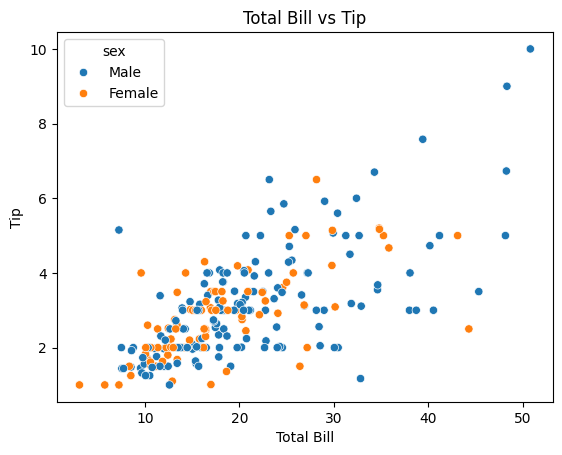

In [40]:
# Task 7
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Total Bill vs Tip")
plt.show()

# There is +ve relationship between tip and bill as people who are ordering more give a higher tip, also separated by color hue for genders

C:\Users\Lab\AppData\Local\Temp\ipykernel_12704\2392523045.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = df.groupby('day')['total_bill'].mean()


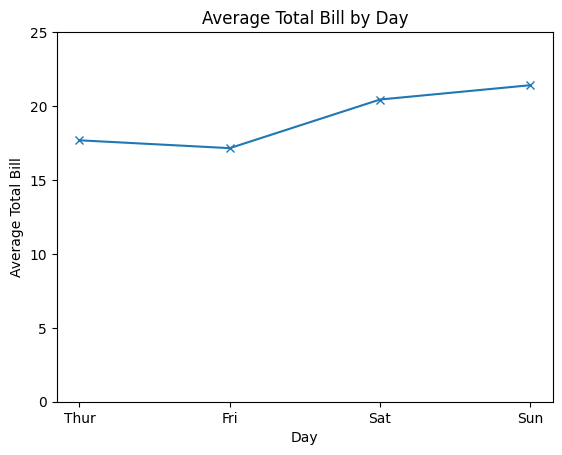

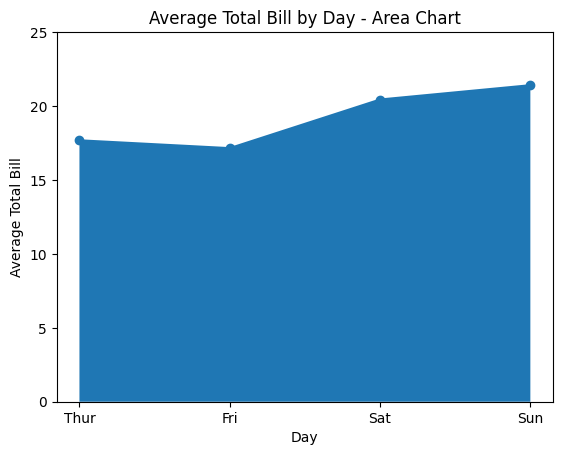

In [ ]:
# Task 8
avg = df.groupby('day')['total_bill'].mean()

# Line 
plt.plot(avg.index, avg.values, marker='x')
plt.xlabel('Day')
plt.ylabel('Average Total Bill')
plt.title('Average Total Bill by Day')
plt.ylim(bottom=0)
plt.ylim(0, 25)
plt.yticks(range(0, 26, 5))
plt.show()

# Area 
plt.fill_between(avg.index, avg.values)
plt.plot(avg.index, avg.values, marker='o')
plt.xlabel('Day')
plt.ylabel('Average Total Bill')
plt.ylim(0, 25)
plt.yticks(range(0, 26, 5))
plt.title('Average Total Bill by Day - Area Chart')
plt.show()

# area fill shows the total part of graph covered while the line plot just gives the trend of the data. it shades the data under the line.

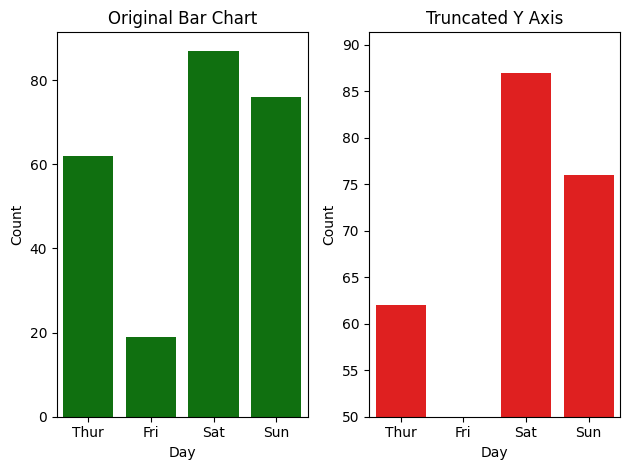

In [62]:
# Task 9

# Original bar chart

# row col pos for subplot
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='day', color='green')
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Original Bar Chart')
plt.ylim(bottom=0)

# Truncated y axis
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='day', color='red')
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Truncated Y Axis')
plt.ylim(bottom=50)

plt.tight_layout()
plt.show()

# there is one less column as we are viewing data above count = 50 so friday gets truncated...